# Viscous fingering of a Darcy fluid in a porous rectangle with periodic boundary conditions

$$
\mathbb{S}_{\psi,c}
\begin{cases}
\Omega = [-\mathcal{A}X/2, \mathcal{A}X/2] \times [0, X] & \text{aspect ratio } \mathcal{A}=\mathcal{O}(1)\\
c_0(x,y)=\lim_{\epsilon\to0}\frac{1}{2}\left(1+\text{erf}\left(-\frac{x}{\epsilon X}\right)\right)+\mathcal{N}(x,y) & \text{peturbed initial concentration} \\
c_{\text{D}}(x=-\tfrac{1}{2}\mathcal{A}X,y)=1 & \text{thick left boundary} \\ 
c_{\text{D}}(x=\tfrac{1}{2}\mathcal{A}X,y)=0 & \text{thin right boundary} \\
\psi_{\text{D}}(x=-\tfrac{1}{2}\mathcal{A}X,y)=0 & \text{no-penetration on left boundary} \\ 
\psi_{\text{D}}(x=\tfrac{1}{2}\mathcal{A}X,y)=0 & \text{no-penetration on right boundary} \\ 
c(x,y=0)=c(x,y=X) & \text{periodic upper and lower concentration} \\
\psi(x,y=0)=\psi(x,y=X) & \text{periodic upper and lower streamfunction} \\
\phi = 1 & \text{constant porosity} \\
\mathsf{D} = \mathsf{I} & \text{constant isotropic permeability} \\
\mathsf{K} = \mathsf{I} & \text{constant isotropic dispersion} \\
\mu(c) = \exp(-\Lambda c) & \text{exponential viscosity} \\
\textbf{e}_{\text{in}}=\pm\textbf{e}_x & \text{horizontal injection} \\
\end{cases}
$$

In [1]:
from lucifex.fdm import AB2, CN
from lucifex.sim import run
from lucifex.plt import plot_colormap, save_figure, create_animation, display_animation
from py.A10_darcy_fingering import darcy_fingering_rectangle

simulation = darcy_fingering_rectangle(
    aspect=2.0,
    Nx=128,
    Ny=128,
    cell='quadrilateral', 
    scaling='advective',
    Pe=1000.0,
    Lmbda=2.0, 
    left_to_right=True,
    bc_type='periodic',
    c_limits=True,
    D_adv=AB2,
    D_diff=CN,
    dt_max=0.05,
)

n_stop = 200
dt_init = 1e-6
n_init = 5
run(simulation, n_stop=n_stop, dt_init=dt_init, n_init=n_init)

c, psi = simulation['c', 'psi']

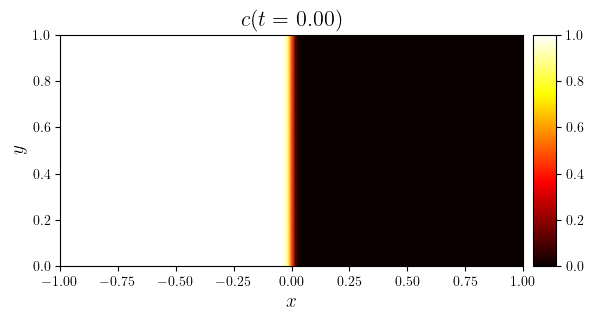

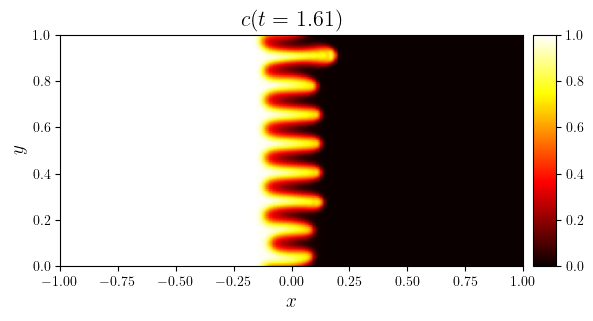

In [2]:
time_indices = (0, -1)
for i in time_indices:
    fig, ax = plot_colormap(c.series[i], title=f'$c(t={c.time_series[i]:.2f})$')
    save_figure(f'{c.name}(t={c.time_series[i]:.2f})', thumbnail=(i is time_indices[-1]))(fig)

In [3]:
slc = slice(0, None, 2)
titles = [f'$c(t={t:.3f})$' for t in c.time_series[slc]]

anim = create_animation(
    plot_colormap,
    colorbar=False,
)(c.series[slc], title=titles)
anim_path = save_figure(f'{c.name}(x,y,t)', return_path=True)(anim)

display_animation(anim_path)